In [1]:
import numpy as np
from PIL import Image
from IPython.display import display

In [2]:
from __future__ import annotations

NUM_ROWS = 28
NUM_COLS = 28
NUM_LABELS = 10

class Data:
  def __init__(self, pixels: list[list[int]], label: int):
    self.pixels = pixels
    self.flattened_pixels: list[int] = []
    for row in self.pixels:
      assert len(row) == NUM_ROWS
      self.flattened_pixels.extend(row)
    self.flattened_pixels = [pixel / 255.0 for pixel in self.flattened_pixels]
    
    self.label = label
  
  @classmethod
  def from_csv_row(cls, csv: list[int]) -> Data:
    label = csv[0]
    pixels: list[list[int]] = []
    for row in range(NUM_ROWS):
      start_index = 1 + row * NUM_ROWS
      pixels.append(csv[start_index : start_index + NUM_COLS])

    return cls(pixels, label)
  
  def to_image(self) -> Image:
    pixel_array = np.array(self.pixels, dtype=np.uint8)
    return Image.fromarray(pixel_array, mode='L')
  
  def label_to_one_hot(self) -> list[int]:
    result = [0] * NUM_LABELS
    result[self.label] = 1
    return result

In [3]:
lines: list[str] = []
datas: list[Data] = []

with open('data/MNIST_CSV/mnist_train.csv') as f:
  lines = f.readlines()

for line in lines:
  datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [4]:
print(datas[0].label)
print(datas[0].label_to_one_hot())
display(datas[0].to_image())

5
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [5]:
distinct_labels = set()
for data in datas:
  distinct_labels.add(data.label)

In [6]:
distinct_labels

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

## Train

In [ ]:
from src.deep_learning.layer import get_layer
from src.deep_learning.multi_layer_perceptron import MultiLayerPerceptron
from src.deep_learning.op import TANH
from src.deep_learning.value import Value

from src.deep_learning.util import zero_all_gradients
from src.deep_learning.util import softmax
from src.deep_learning.util import cross_entropy
from datetime import datetime

In [ ]:
# build graph

input_values = [Value(0.0, label=f'pixel_{i}') for i in range(NUM_ROWS*NUM_COLS)]
output_values = [Value(0.0, label=f'label_{i}') for i in range(len(distinct_labels))]

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_layer(128, NUM_ROWS*NUM_COLS, TANH),
        get_layer(NUM_LABELS, 128),
    ],
)
predicted_output = multi_layer_perceptron.build_graph(input_values)
softmax_output = softmax(predicted_output)
loss = cross_entropy(
    distribution=output_values,
    predicted_distribution=softmax_output,
)

### debugging

In [29]:
loss.gradient

0.0

In [30]:
for value in softmax_output:
  print(value.gradient)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [31]:
import matplotlib.pyplot as plt

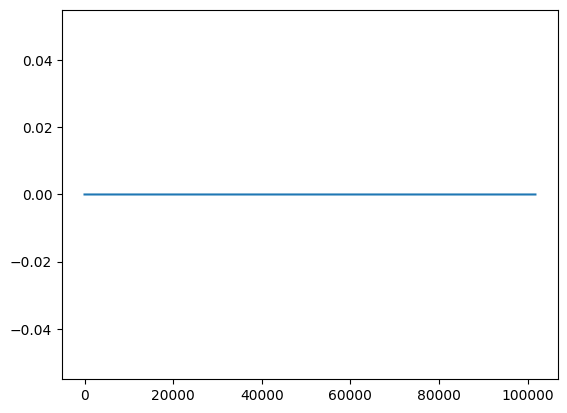

In [32]:
i = 0
gradients: list[float] = []
for layer in multi_layer_perceptron.layers:
  for neuron in layer.neurons:
    for weight in neuron.weight_values:
      gradients.append(weight.gradient)
    gradients.append(neuron.bias_value.gradient)
plt.plot(gradients)

### end debugging

In [33]:
data_index = 0

In [34]:
losses: list[float] = []

In [35]:
for i in range(len(datas) * 2):
  # compute loss
  data = datas[data_index]
  for input_value, pixel in zip(input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  loss.forward()
  losses.append(loss.data)

  if i % 100 == 0 and i > 0:
    window = losses[-100:]
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} mean_t100_loss={sum(window)/len(window):.4f}')

  # backwards
  zero_all_gradients(loss)
  loss.gradient = 1.0
  loss.backward()

  # adjust parameters
  alpha = 0.01
  for layer in multi_layer_perceptron.layers:
    for neuron in layer.neurons:
      for weight_value in neuron.weight_values:
        weight_value.data = weight_value.data + (weight_value.gradient * -alpha)
      neuron.bias_value.data = neuron.bias_value.data + (neuron.bias_value.gradient * -alpha)

  # update state
  data_index = (data_index + 1) % len(datas)

20:06:31 i=100 mean_t100_loss=9.4558
20:07:19 i=200 mean_t100_loss=4.8198
20:08:18 i=300 mean_t100_loss=4.3422
20:09:11 i=400 mean_t100_loss=3.3254
20:10:01 i=500 mean_t100_loss=3.9534
20:10:53 i=600 mean_t100_loss=3.1317
20:11:47 i=700 mean_t100_loss=3.1245
20:12:41 i=800 mean_t100_loss=2.6092
20:13:37 i=900 mean_t100_loss=2.2386
20:14:36 i=1000 mean_t100_loss=2.4689
20:15:35 i=1100 mean_t100_loss=2.9370
20:16:35 i=1200 mean_t100_loss=2.2066
20:17:31 i=1300 mean_t100_loss=1.5834
20:18:29 i=1400 mean_t100_loss=1.9016
20:19:40 i=1500 mean_t100_loss=1.6254
20:20:53 i=1600 mean_t100_loss=1.4312
20:22:05 i=1700 mean_t100_loss=1.3129
20:23:20 i=1800 mean_t100_loss=0.7999
20:24:27 i=1900 mean_t100_loss=1.2086
20:25:30 i=2000 mean_t100_loss=1.2258
20:26:35 i=2100 mean_t100_loss=1.9376
20:27:36 i=2200 mean_t100_loss=0.7153
20:28:32 i=2300 mean_t100_loss=1.0339
20:29:32 i=2400 mean_t100_loss=1.1465
20:30:36 i=2500 mean_t100_loss=1.3286
20:31:34 i=2600 mean_t100_loss=0.9591
20:32:27 i=2700 mean_

In [36]:
import matplotlib.pyplot as plt

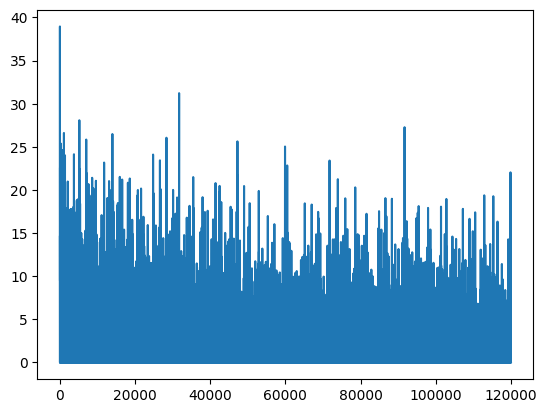

In [37]:
# noisy
plt.plot(losses)

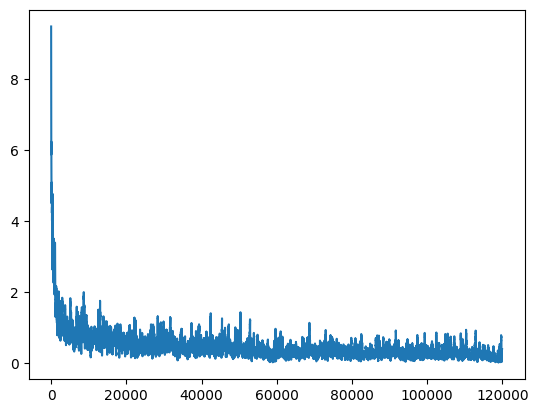

In [38]:
# smooth
mean_t100_losses: list[float] = []
for i in range(100, len(losses)):
  mean_t100_losses.append(sum(losses[i-100:i]) / 100)

plt.plot(mean_t100_losses)

## Pickle

In [8]:
import pickle

class Model:
  def __init__(
      self,
      input_values: list[Value],
      output_values: list[Value],
      multi_layer_perceptron_output: Value,
      softmax_output: list[Value],
      loss: Value,
  ):
    self.input_values = input_values
    self.output_values = output_values
    self.multi_layer_perceptron_output = multi_layer_perceptron_output
    self.softmax_output = softmax_output
    self.loss = loss

In [ ]:
model = Model(
    input_values=input_values,
    output_values=output_values,
    multi_layer_perceptron_output=predicted_output,
    softmax_output=softmax_output,
    loss=loss,
)

# NOTE: commented out after running to prevent dumb accidental overwrite errors
# with open('data/MNIST_CSV/model.pkl', 'wb') as file:
#   pickle.dump(model, file)

In [9]:
model: Model = None
with open('data/MNIST_CSV/model.pkl', 'rb') as file:
  model = pickle.load(file)

## Predict

In [10]:
data = datas[0]
for input_value, pixel in zip(model.input_values, data.flattened_pixels, strict=True):
  input_value.data = float(pixel)
for output_value, label_one_hot in zip(model.output_values, data.label_to_one_hot(), strict=True):
  output_value.data = label_one_hot
model.loss.forward()

for i, p_label in enumerate(model.softmax_output):
  print(f'P({i}): {p_label.data:4f}')

prediction = max(range(len(model.softmax_output)), key=lambda i: model.softmax_output[i].data)
prediction

P(0): 0.000176
P(1): 0.000550
P(2): 0.003777
P(3): 0.010542
P(4): 0.000000
P(5): 0.984933
P(6): 0.000000
P(7): 0.000000
P(8): 0.000015
P(9): 0.000008


5

## Test

In [11]:
lines: list[str] = []
test_datas: list[Data] = []

with open('data/MNIST_CSV/mnist_test.csv') as f:
  lines = f.readlines()

for line in lines:
  test_datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [12]:
print(test_datas[0].label)
print(test_datas[0].label_to_one_hot())
display(test_datas[0].to_image())

7
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


In [21]:
class TestOutcome:
  def __init__(
      self,
      test_case_index: int,
      correct_label: int,
      predicted_label: int,
      predicted_label_to_probability: dict[int, float],
  ):
    test_case_index = test_case_index
    self.correct_label = correct_label
    self.predicted_label = predicted_label
    self.predicted_label_to_probability = predicted_label_to_probability

  def __repr__(self) -> str:
    return f'{self.__class__.__name__}({self.__dict__})'

In [27]:
test_outcomes: list[TestOutcome] = []
incorrect_test_outcomes: list[TestOutcome] = []

In [29]:
from datetime import datetime

In [30]:
for i in range(len(test_datas)):
  # compute prediction
  data = test_datas[i]
  for input_value, pixel in zip(model.input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(model.output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  model.loss.forward()

  predicted_label_to_probability: dict[int, float] = {}
  for label, probability in enumerate(model.softmax_output):
    predicted_label_to_probability[label] = probability.data

  predicted_label = max(predicted_label_to_probability.keys(), key=lambda label: predicted_label_to_probability[label])
  
  test_outcome = TestOutcome(
      test_case_index=i,
      correct_label=data.label,
      predicted_label=predicted_label,
      predicted_label_to_probability=predicted_label_to_probability,
  )
  
  # update state
  test_outcomes.append(test_outcome)
  if test_outcome.correct_label != test_outcome.predicted_label:
    incorrect_test_outcomes.append(test_outcome)

  if i % 100 == 0 and i > 0:
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} current_score={(i - len(incorrect_test_outcomes)) / i:.4f}')

14:51:12 i=100 current_score=0.9200
14:51:23 i=200 current_score=0.9450
14:51:35 i=300 current_score=0.9433
14:51:46 i=400 current_score=0.9350
14:51:57 i=500 current_score=0.9360
14:52:08 i=600 current_score=0.9333
14:52:19 i=700 current_score=0.9329
14:52:30 i=800 current_score=0.9313
14:52:42 i=900 current_score=0.9333
14:52:53 i=1000 current_score=0.9310
14:53:05 i=1100 current_score=0.9291
14:53:16 i=1200 current_score=0.9242
14:53:28 i=1300 current_score=0.9185
14:53:39 i=1400 current_score=0.9193
14:53:51 i=1500 current_score=0.9193
14:54:04 i=1600 current_score=0.9194
14:54:17 i=1700 current_score=0.9206
14:54:29 i=1800 current_score=0.9189
14:54:40 i=1900 current_score=0.9184
14:54:52 i=2000 current_score=0.9175
14:55:04 i=2100 current_score=0.9157
14:55:15 i=2200 current_score=0.9141
14:55:27 i=2300 current_score=0.9148
14:55:38 i=2400 current_score=0.9142
14:55:49 i=2500 current_score=0.9148
14:56:00 i=2600 current_score=0.9169
14:56:11 i=2700 current_score=0.9170
14:56:22 i

In [31]:
score = (len(test_outcomes) - len(incorrect_test_outcomes)) / len(test_outcomes)
print(f'{score:4f}=')

0.938719=
